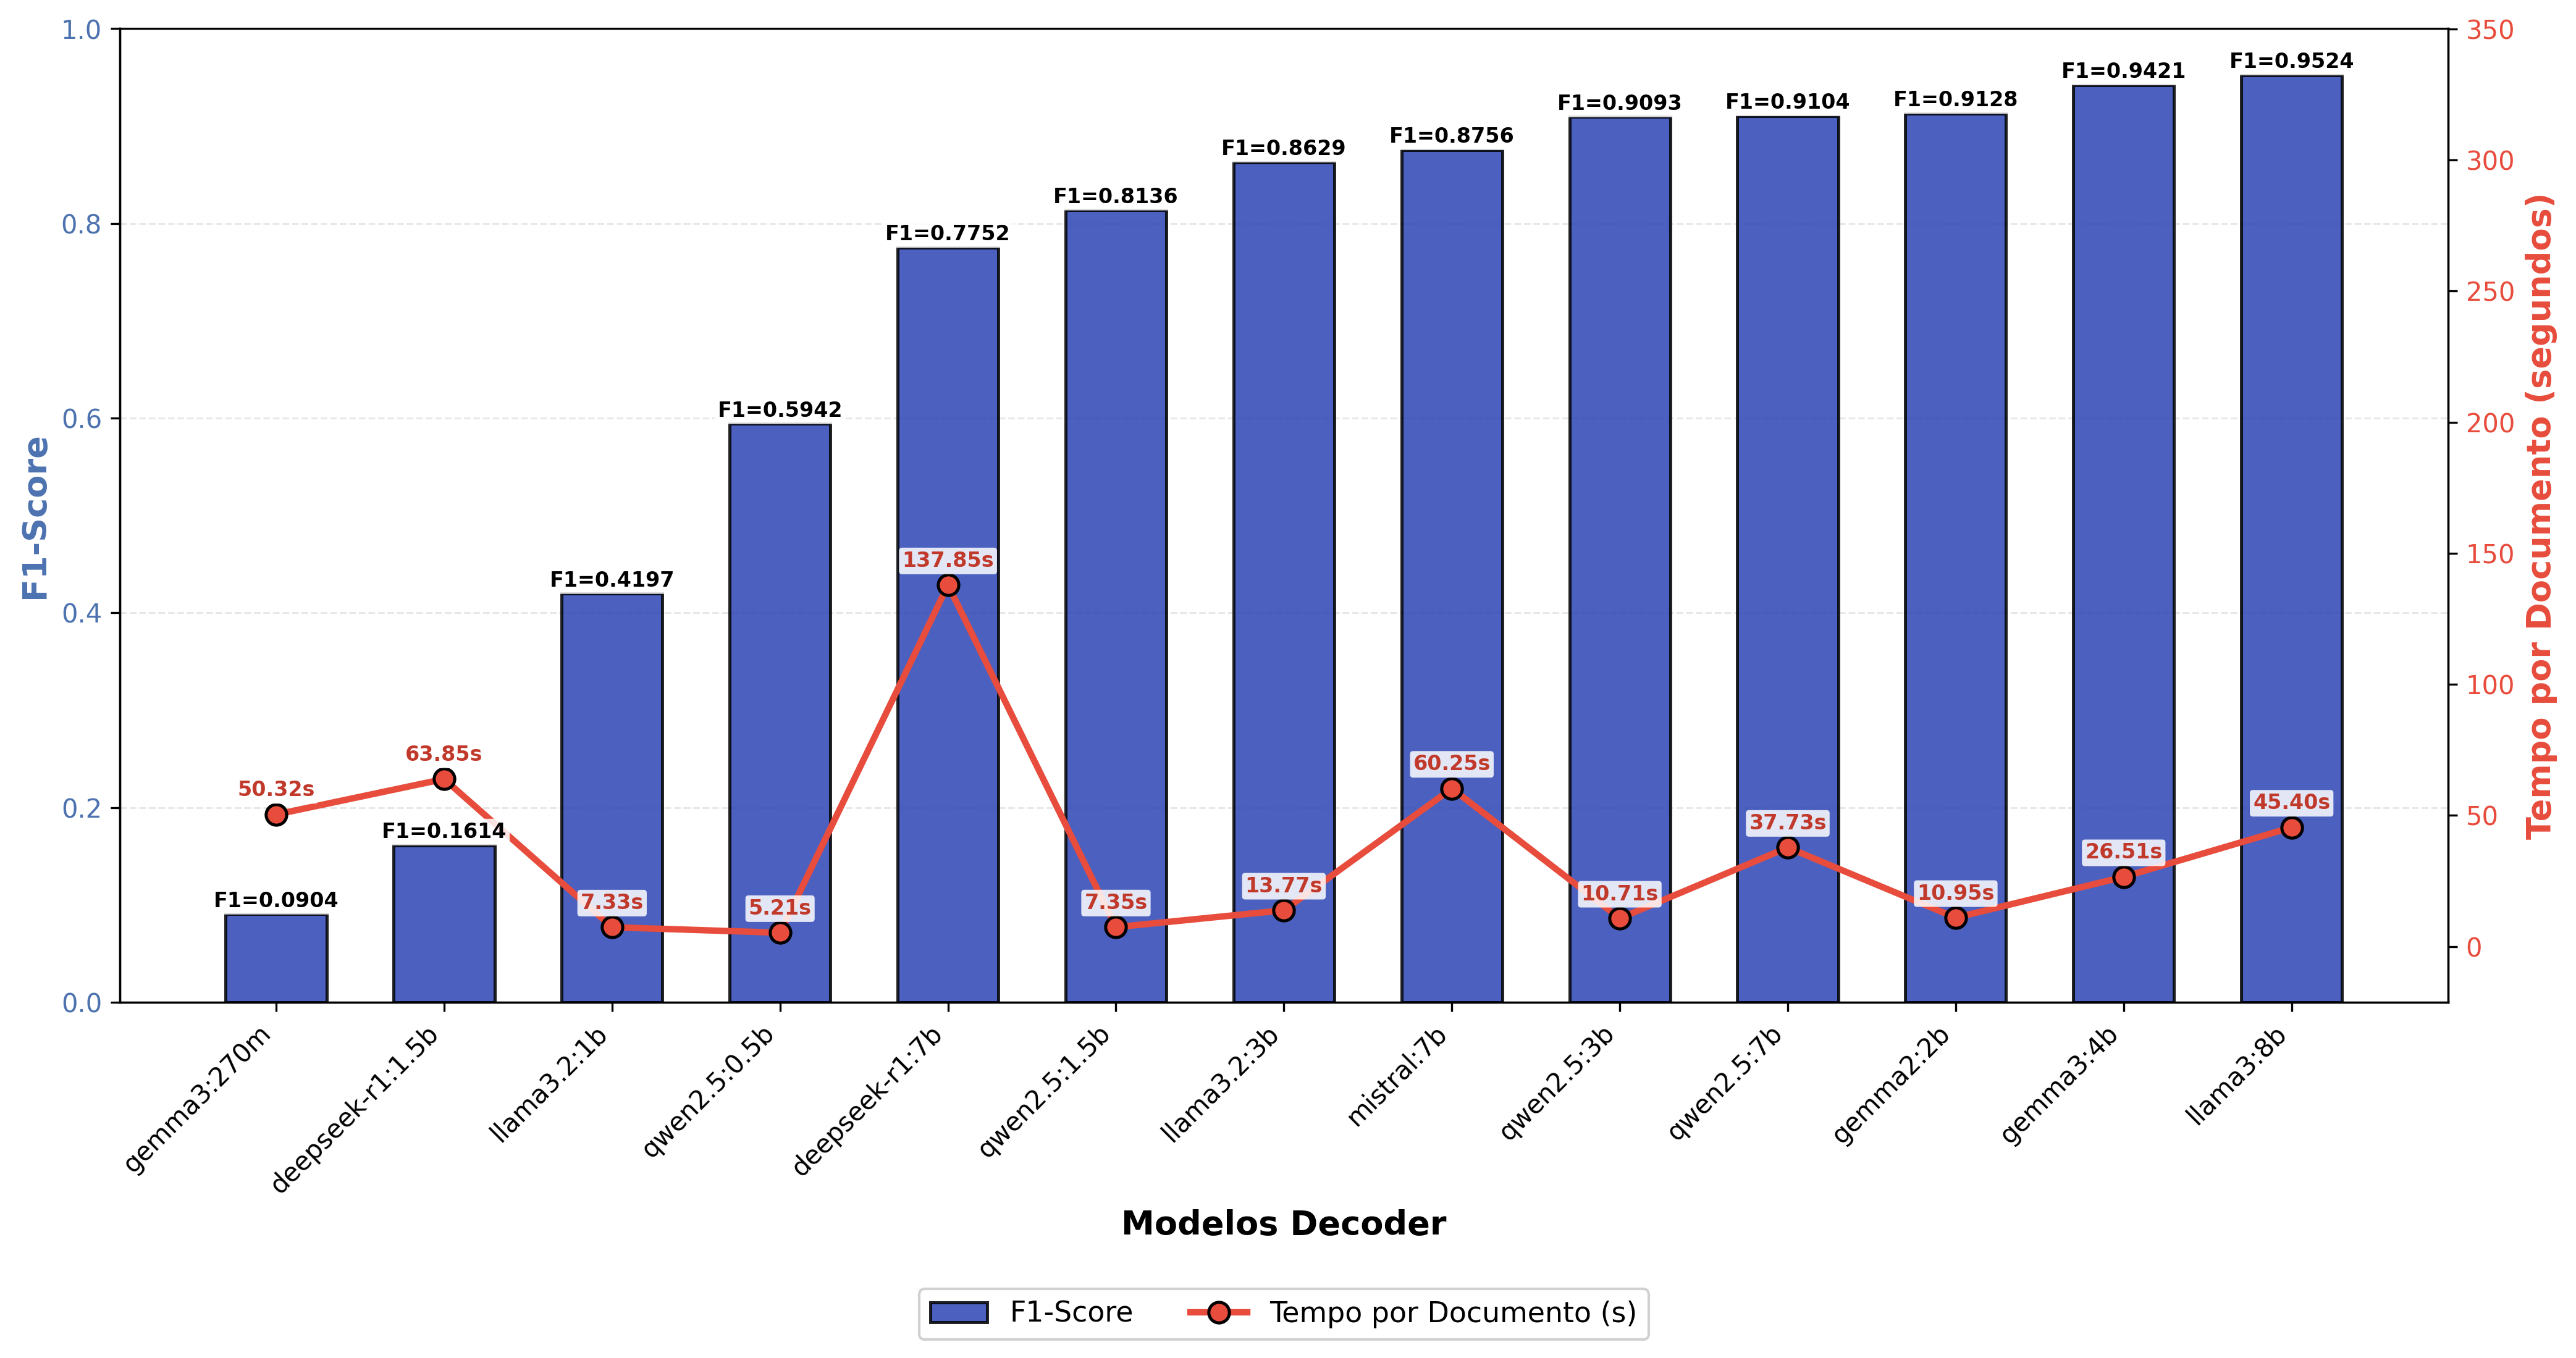


Dados dos Modelos Decoder - F1-Score vs Tempo por Documento:
Modelo                    F1-Score        Tempo/Doc (s)  
-------------------------------------------------------
gemma3:270m               0.0904          50.32          
deepseek-r1:1.5b          0.1614          63.85          
llama3.2:1b               0.4197          7.33           
qwen2.5:0.5b              0.5942          5.21           
deepseek-r1:7b            0.7752          137.85         
qwen2.5:1.5b              0.8136          7.35           
llama3.2:3b               0.8629          13.77          
mistral:7b                0.8756          60.25          
qwen2.5:3b                0.9093          10.71          
qwen2.5:7b                0.9104          37.73          
gemma2:2b                 0.9128          10.95          
gemma3:4b                 0.9421          26.51          
llama3:8b                 0.9524          45.40          


In [6]:
# ==========================================
# Decoder Models: F1-Score vs Tempo por Documento
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados de métricas do decoder
df_metrics = pd.read_csv("metric_results/decoder_processing_averages.csv")

# Dados de F1-Score dos modelos decoder
decoder_f1_scores = {
    "mistral:7b": 0.8756,
    "llama3:8b": 0.9524,
    "gemma2:2b": 0.9128,
    "qwen2.5:0.5b": 0.5942,
    "qwen2.5:1.5b": 0.8136,
    "qwen2.5:3b": 0.9093,
    "qwen2.5:7b": 0.9104,
    "llama3.2:1b": 0.4197,
    "llama3.2:3b": 0.8629,
    "deepseek-r1:1.5b": 0.1614,
    "deepseek-r1:7b": 0.7752,
    "gemma3:270m": 0.0904,
    "gemma3:4b": 0.9421,
}

# Preparar dados para plotagem
models = []
f1_scores = []
time_per_doc = []

for idx, row in df_metrics.iterrows():
    model = row["modelo"]
    if model in decoder_f1_scores:
        models.append(model)
        f1_scores.append(decoder_f1_scores[model])
        # Tempo total dividido por 40 arquivos
        time_per_doc.append(row["tempo_total_s"] / 40)

# Converter para arrays
f1_scores = np.array(f1_scores)
time_per_doc = np.array(time_per_doc)

# Ordenar por F1-Score em ordem crescente
sorted_indices = np.argsort(f1_scores)
f1_scores = f1_scores[sorted_indices]
time_per_doc = time_per_doc[sorted_indices]
models = [models[i] for i in sorted_indices]

# ==========================================
# Criar figura com eixos duplos
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=300)

x_pos = np.arange(len(models))
width = 0.6

# Eixo Y esquerda: F1-Score (barras)
bars = ax1.bar(
    x_pos,
    f1_scores,
    width=width,
    color="#2C45B4",
    alpha=0.85,
    edgecolor="black",
    linewidth=1.2,
    label="F1-Score",
    zorder=2,
)

ax1.set_xlabel("Modelos Decoder", fontsize=13, fontweight="bold")
ax1.set_ylabel("F1-Score", fontsize=13, fontweight="bold", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha="right", fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.7, zorder=0)
ax1.spines["top"].set_visible(False)

# ==========================================
# Eixo Y direita: Tempo por documento
# ==========================================
ax2 = ax1.twinx()

# Definir ylim do ax2 ANTES das anotações para que a conversão
# de coordenadas seja calculada com os limites finais corretos.
t_min = time_per_doc.min()
t_max = time_per_doc.max()
ax2.set_ylim(
    t_min - (t_max - t_min) * 0.2,
    t_max + (t_max - t_min) * 1.6,  # bastante espaço no topo
)

line = ax2.plot(
    x_pos,
    time_per_doc,
    color="#E74C3C",
    marker="o",
    linewidth=2.5,
    markersize=8,
    markeredgecolor="black",
    markeredgewidth=1.2,
    label="Tempo por Documento (s)",
    zorder=3,
)

ax2.set_ylabel(
    "Tempo por Documento (segundos)",
    fontsize=13,
    fontweight="bold",
    color="#E74C3C",
)
ax2.tick_params(axis="y", labelcolor="#E74C3C")

# ==========================================
# Anotações de F1 desenhadas em ax2
# para garantir que ficam na frente da linha.
# Conversão: coordenada y de ax1 → display → ax2
# ==========================================
ax1_to_display = ax1.transData
display_to_ax2 = ax2.transData.inverted()

for bar, f1 in zip(bars, f1_scores):
    x_data = bar.get_x() + bar.get_width() / 2
    y_ax1 = bar.get_height() + 0.003          # logo acima do topo da barra
    x_disp, y_disp = ax1_to_display.transform((x_data, y_ax1))
    x_ax2, y_ax2 = display_to_ax2.transform((x_disp, y_disp))

    ax2.text(
        x_ax2,
        y_ax2,
        f"F1={f1:.4f}",
        ha="center",
        va="bottom",          # cresce para CIMA a partir do topo da barra
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# Anotações de tempo
for x, t in zip(x_pos, time_per_doc):
    ax2.text(
        x,
        t + (t_max - t_min) * 0.04,   # pequeno offset proporcional ao range
        f"{t:.2f}s",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#C0392B",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# ==========================================
# Legenda FORA do gráfico — abaixo do eixo X
# ==========================================
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + line,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

# ==========================================
# Salvar figura
# ==========================================
plt.savefig("decoder_f1_vs_tempo_documento.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nDados dos Modelos Decoder - F1-Score vs Tempo por Documento:")
print(f"{'Modelo':<25} {'F1-Score':<15} {'Tempo/Doc (s)':<15}")
print("-" * 55)
for model, f1, t in zip(models, f1_scores, time_per_doc):
    print(f"{model:<25} {f1:<15.4f} {t:<15.2f}")

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# ==========================================
# Dados dos modelos
# ==========================================

models = {
    "BERTimbau Base": {"params_m": 110, "f1": 0.9510},
    "BERT Base": {"params_m": 110, "f1": 0.9500},
    "RoBERTa Base": {"params_m": 110, "f1": 0.9485},
    "DistilBERT": {"params_m": 67, "f1": 0.9439},
    "ELECTRA Base": {"params_m": 110, "f1": 0.9434},
    "ALBERT Base": {"params_m": 11.8, "f1": 0.9010}
}

In [ ]:

# ==========================================
# Preparação dos dados
# ==========================================

names = list(models.keys())
f1_scores = [models[m]["f1"] for m in names]
params = [models[m]["params_m"] for m in names]

# ==========================================
# Configuração do gráfico de barras
# ==========================================

plt.figure(figsize=(10, 6), dpi=300)

bars = plt.bar(
    names,
    f1_scores,
    color="#4C72B0",
    alpha=0.85
)

# Adiciona valores acima das barras
for bar, f1, p in zip(bars, f1_scores, params):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f"F1={f1:.3f}\n{p:.1f}M params",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ==========================================
# Estilo acadêmico
# ==========================================

plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Modelos", fontsize=12)

plt.ylim(0.89, 0.955)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Remove bordas superiores e direitas
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=20, ha="right", fontsize=10)

plt.tight_layout()

# ==========================================
# Salvar figura
# ==========================================

plt.savefig("encoder_models_f1_bar.png", bbox_inches="tight")

# ==========================================
# Exibição
# ==========================================

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Ler dados de desempenho dos modelos
# ==========================================

df = pd.read_csv("results/encoder/encoder_averages_all_months.csv")

# Mapeamento de nomes dos modelos e número de parâmetros
model_info = {
    "bert-base-uncased": {"name": "BERT Base", "params": 110},
    "bert-base-portuguese-cased": {"name": "BERTimbau Base", "params": 110},
    "bert-base-portuguese-cased_final_model": {"name": "BERTimbau Base (Final)", "params": 110},
    "distilbert-base-uncased": {"name": "DistilBERT", "params": 67},
    "distilbert-base-uncased_final_model": {"name": "DistilBERT (Final)", "params": 67},
    "roberta_base": {"name": "RoBERTa Base", "params": 110},
    "electra-base-discriminator": {"name": "ELECTRA Base", "params": 110},
    "colbert_v2.0": {"name": "ColBERT v2.0", "params": 110},
    "albert-base-v2": {"name": "ALBERT Base", "params": 11.8},
}

# Adicionar informações ao dataframe
df["model_name"] = df["model"].map(lambda x: model_info[x]["name"])
df["params"] = df["model"].map(lambda x: model_info[x]["params"])

print(df)

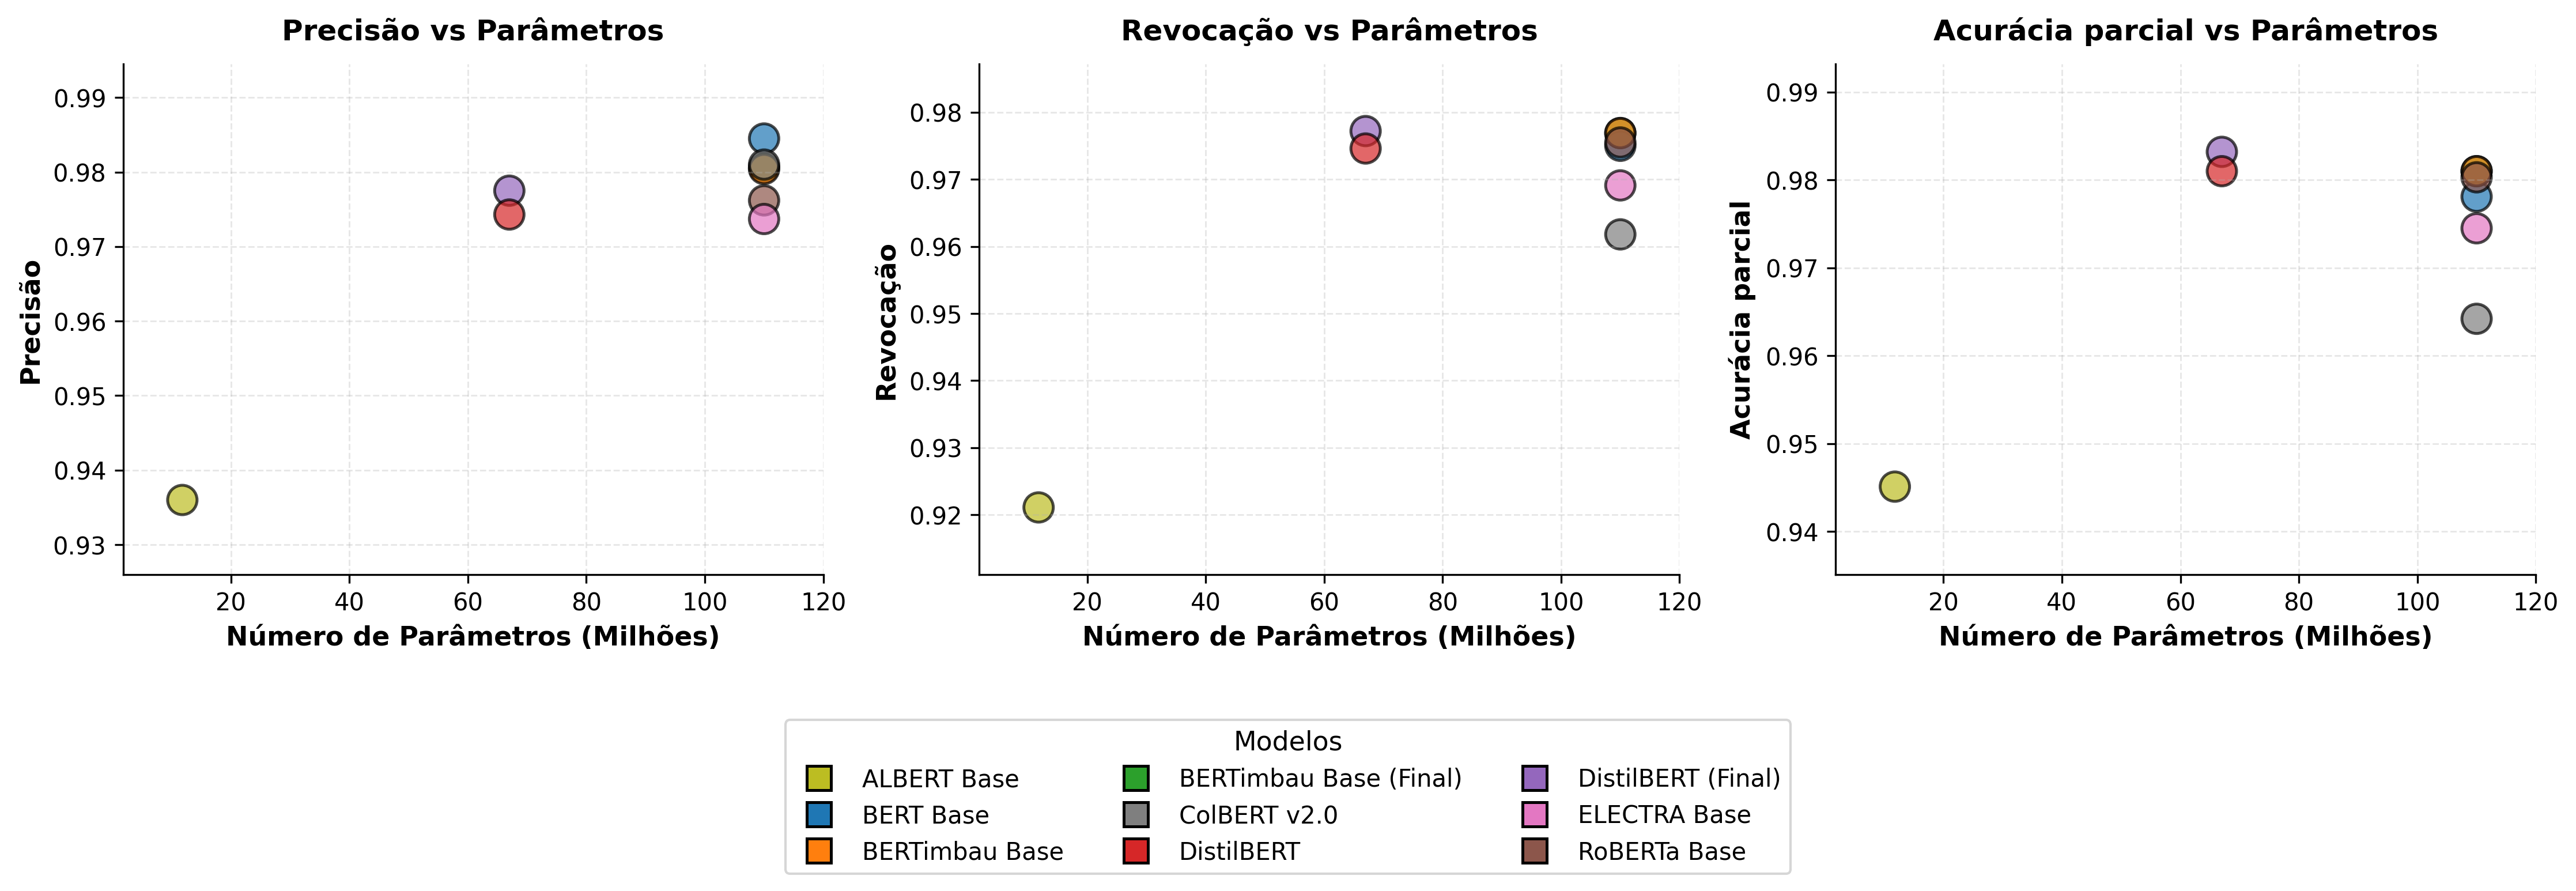

In [4]:
# ==========================================
# Definir palheta de cores para cada modelo
# ==========================================

colors = {
    "BERT Base": "#1f77b4",
    "BERTimbau Base": "#ff7f0e",
    "BERTimbau Base (Final)": "#2ca02c",
    "DistilBERT": "#d62728",
    "DistilBERT (Final)": "#9467bd",
    "RoBERTa Base": "#8c564b",
    "ELECTRA Base": "#e377c2",
    "ColBERT v2.0": "#7f7f7f",
    "ALBERT Base": "#bcbd22",
}

color_list = [colors[name] for name in df["model_name"]]

# ==========================================
# Criar figura com 3 subplots
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)

# Configuração geral
metrics = ["precisão", "revocação", "acurácia parcial"]
metric_cols = ["precisão", "revocação", "acurácia parcial"]

for idx, (ax, metric) in enumerate(zip(axes, metric_cols)):
    
    # Scatter plot
    scatter = ax.scatter(
        df["params"],
        df[metric],
        s=150,
        c=color_list,
        alpha=0.7,
        edgecolors="black",
        linewidth=1.2,
    )
    
    # Estilo acadêmico
    ax.set_xlabel("Número de Parâmetros (Milhões)", fontsize=11, fontweight="bold")
    ax.set_ylabel(metric.capitalize(), fontsize=11, fontweight="bold")
    ax.set_title(f"{metric.capitalize()} vs Parâmetros", fontsize=12, fontweight="bold", pad=10)
    
    # Grid
    ax.grid(True, linestyle="--", alpha=0.3, linewidth=0.7)
    
    # Remove bordas superiores e direitas
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Limites dos eixos com padding
    ax.set_xlim(df["params"].min() - 10, df["params"].max() + 10)
    ax.set_ylim(df[metric].min() - 0.01, df[metric].max() + 0.01)

# ==========================================
# Legenda global com marcadores quadrados
# ==========================================

legend_elements = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colors[name], markersize=10, 
               markeredgecolor="black", markeredgewidth=1.2, label=name)
    for name in sorted(colors.keys())
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
    title="Modelos",
    title_fontsize=11,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# ==========================================
# Salvar figura
# ==========================================

plt.savefig("encoder_metrics_vs_params.png", bbox_inches="tight", dpi=300)

# ==========================================
# Exibição
# ==========================================

plt.show()


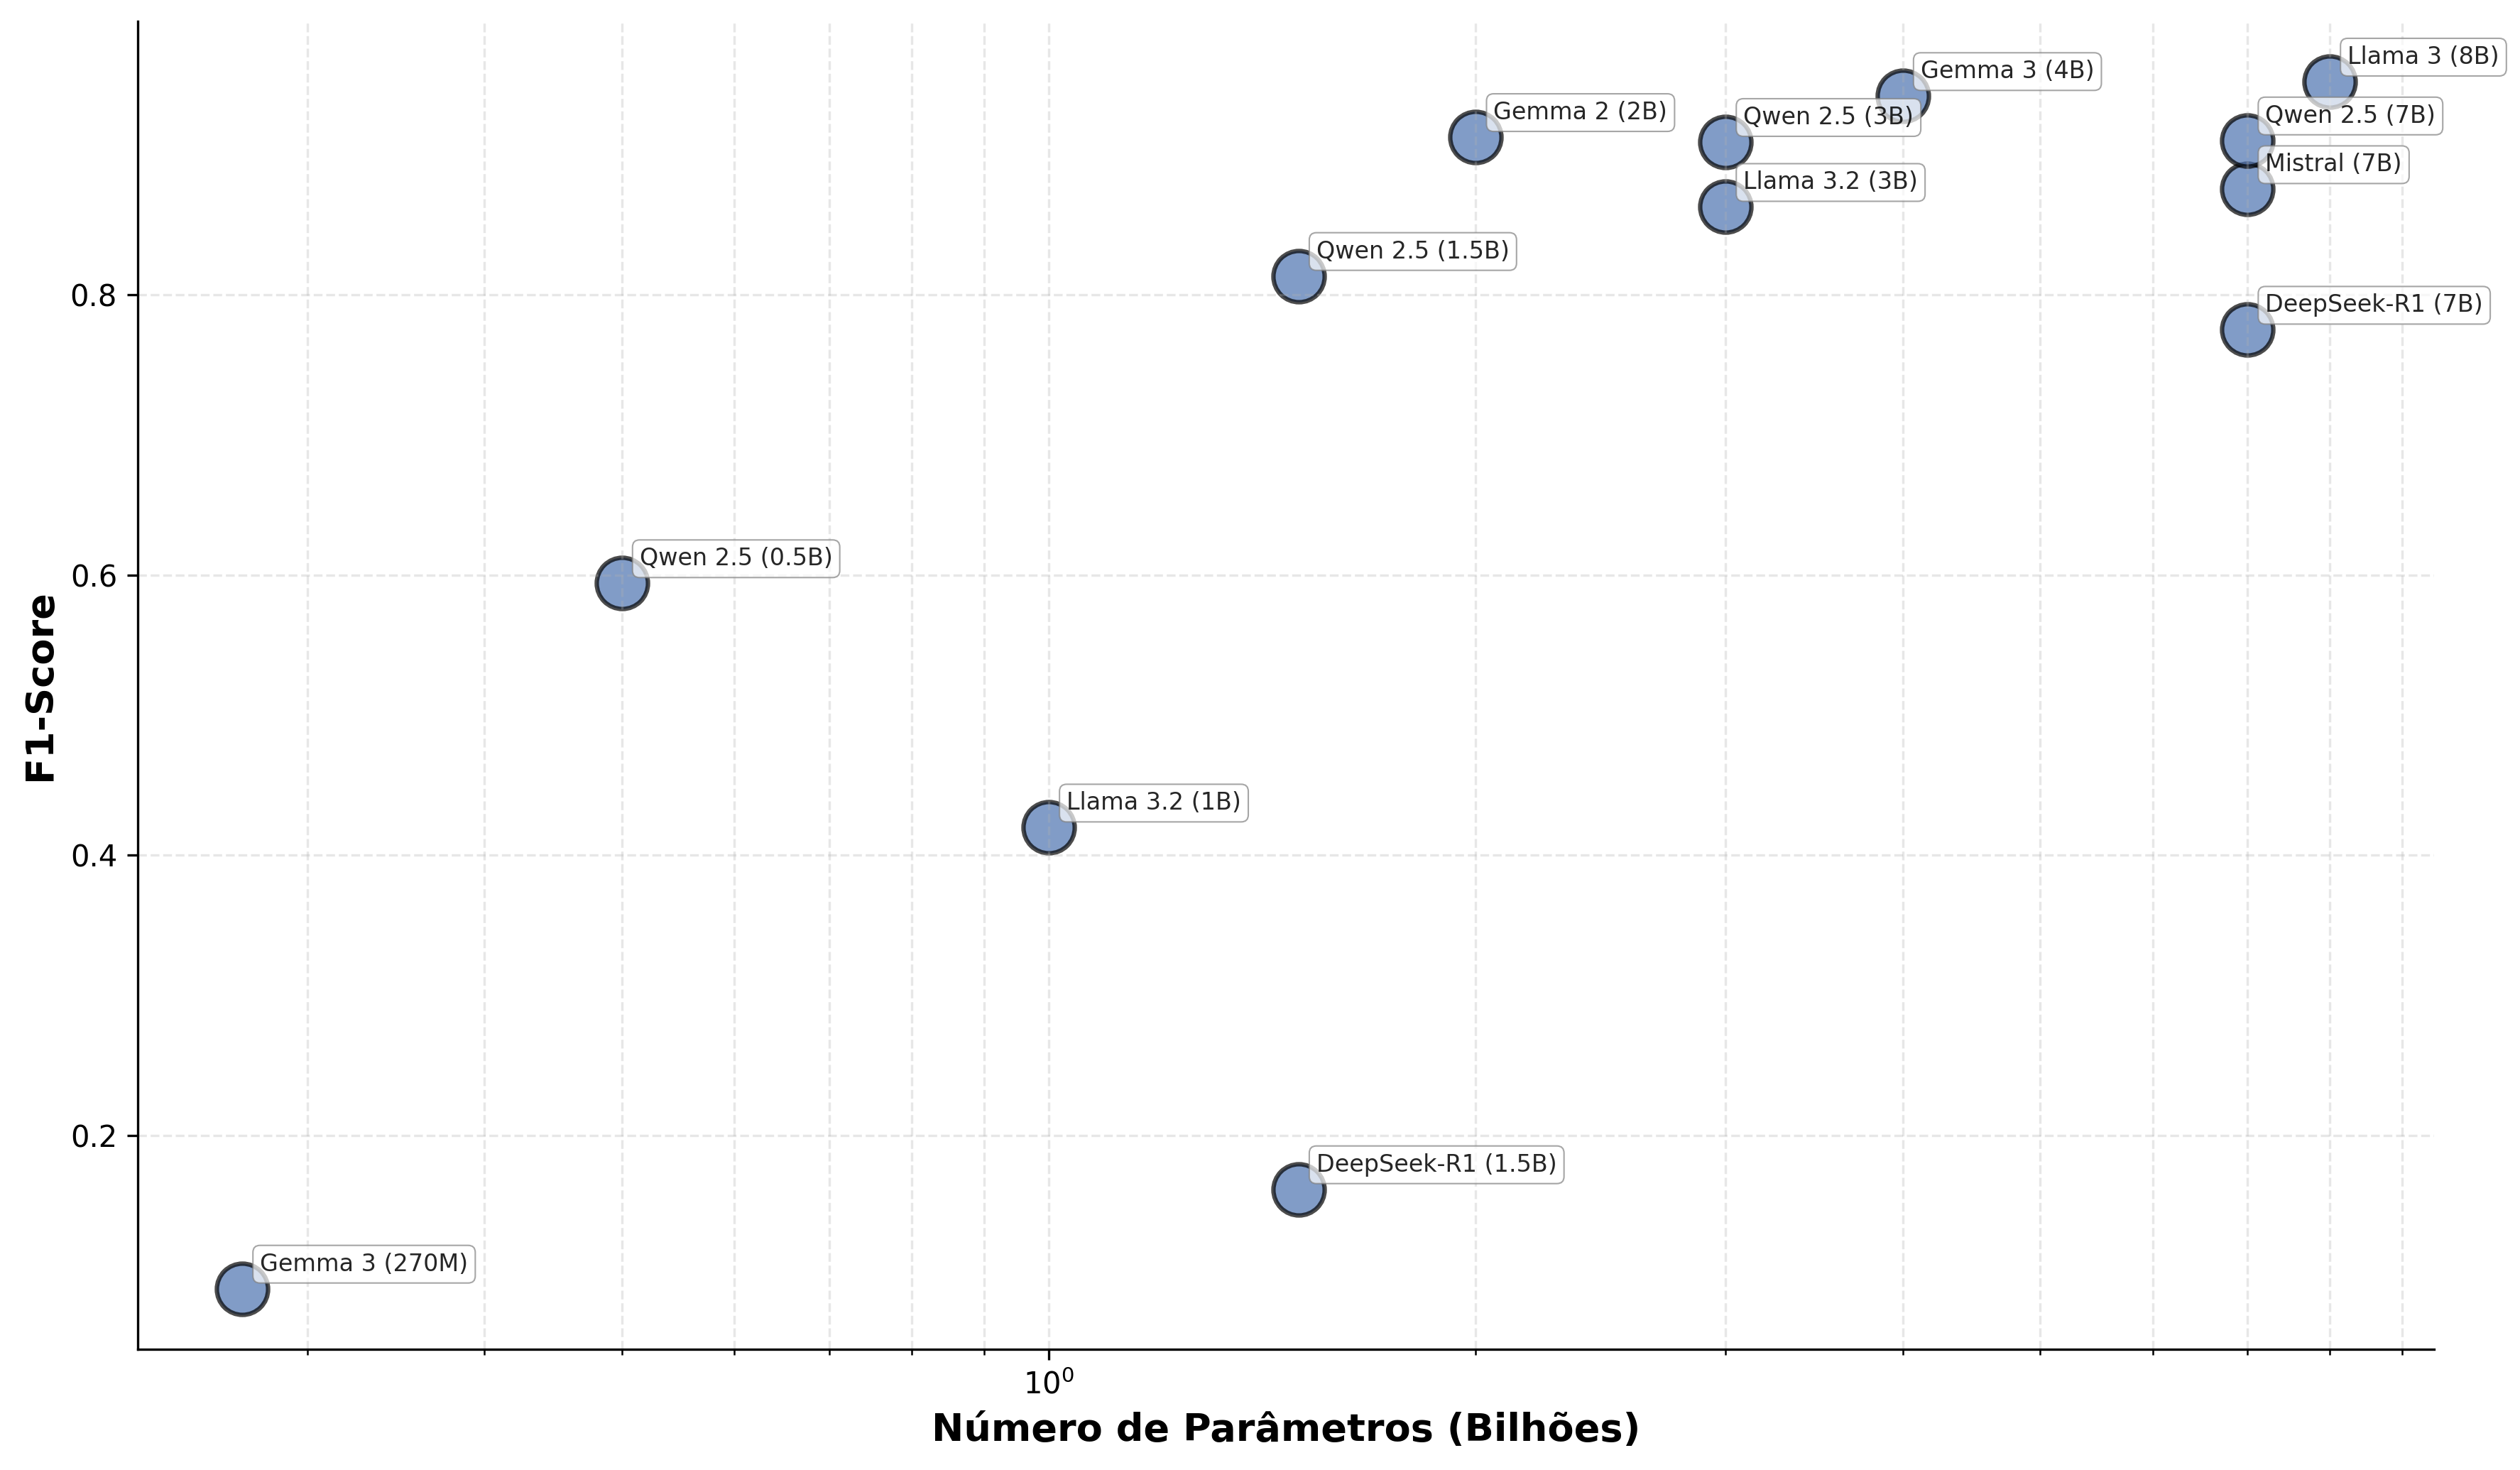


Dados dos Modelos Decoder:
Modelo                    Parâmetros (B)     F1-Score    
-------------------------------------------------------
Mistral (7B)              7.00               0.8756      
Llama 3 (8B)              8.00               0.9524      
Gemma 2 (2B)              2.00               0.9128      
Qwen 2.5 (0.5B)           0.50               0.5942      
Qwen 2.5 (1.5B)           1.50               0.8136      
Qwen 2.5 (3B)             3.00               0.9093      
Qwen 2.5 (7B)             7.00               0.9104      
Llama 3.2 (1B)            1.00               0.4197      
Llama 3.2 (3B)            3.00               0.8629      
DeepSeek-R1 (1.5B)        1.50               0.1614      
DeepSeek-R1 (7B)          7.00               0.7752      
Gemma 3 (270M)            0.27               0.0904      
Gemma 3 (4B)              4.00               0.9421      


In [9]:
# ==========================================
# Decoder Models: F1-Score vs Parâmetros
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dados dos modelos decoder (tabela LaTeX convertida)
decoder_models = {
    "Mistral (7B)": {"params_b": 7, "f1": 0.8756},
    "Llama 3 (8B)": {"params_b": 8, "f1": 0.9524},
    "Gemma 2 (2B)": {"params_b": 2, "f1": 0.9128},
    "Qwen 2.5 (0.5B)": {"params_b": 0.5, "f1": 0.5942},
    "Qwen 2.5 (1.5B)": {"params_b": 1.5, "f1": 0.8136},
    "Qwen 2.5 (3B)": {"params_b": 3, "f1": 0.9093},
    "Qwen 2.5 (7B)": {"params_b": 7, "f1": 0.9104},
    "Llama 3.2 (1B)": {"params_b": 1, "f1": 0.4197},
    "Llama 3.2 (3B)": {"params_b": 3, "f1": 0.8629},
    "DeepSeek-R1 (1.5B)": {"params_b": 1.5, "f1": 0.1614},
    "DeepSeek-R1 (7B)": {"params_b": 7, "f1": 0.7752},
    "Gemma 3 (270M)": {"params_b": 0.27, "f1": 0.0904},
    "Gemma 3 (4B)": {"params_b": 4, "f1": 0.9421},
}

# Preparar dados
names = list(decoder_models.keys())
params = np.array([decoder_models[m]["params_b"] for m in names])
f1_scores = np.array([decoder_models[m]["f1"] for m in names])

# ==========================================
# Criar figura simples
# ==========================================

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Scatter plot
scatter = ax.scatter(
    params,
    f1_scores,
    s=300,
    c="#4C72B0",
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5
)

ax.set_xlabel("Número de Parâmetros (Bilhões)", fontsize=13, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=13, fontweight="bold")
ax.set_xscale("log")
ax.grid(True, linestyle="--", alpha=0.3, which="both")
#ax.set_title("Comparação de Modelos Decoder: F1-Score vs Parâmetros",  fontsize=14, fontweight="bold", pad=15)

# Remover bordas superiores e direitas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adicionar anotações para cada ponto
for name, p, f1 in zip(names, params, f1_scores):
    ax.annotate(
        name,
        xy=(p, f1),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        alpha=0.85,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="gray", linewidth=0.5)
    )

plt.tight_layout()

# ==========================================
# Salvar figura
# ==========================================

plt.savefig("decoder_models_f1_vs_params.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nDados dos Modelos Decoder:")
print(f"{'Modelo':<25} {'Parâmetros (B)':<18} {'F1-Score':<12}")
print("-" * 55)
for name, p, f1 in zip(names, params, f1_scores):
    print(f"{name:<25} {p:<18.2f} {f1:<12.4f}")

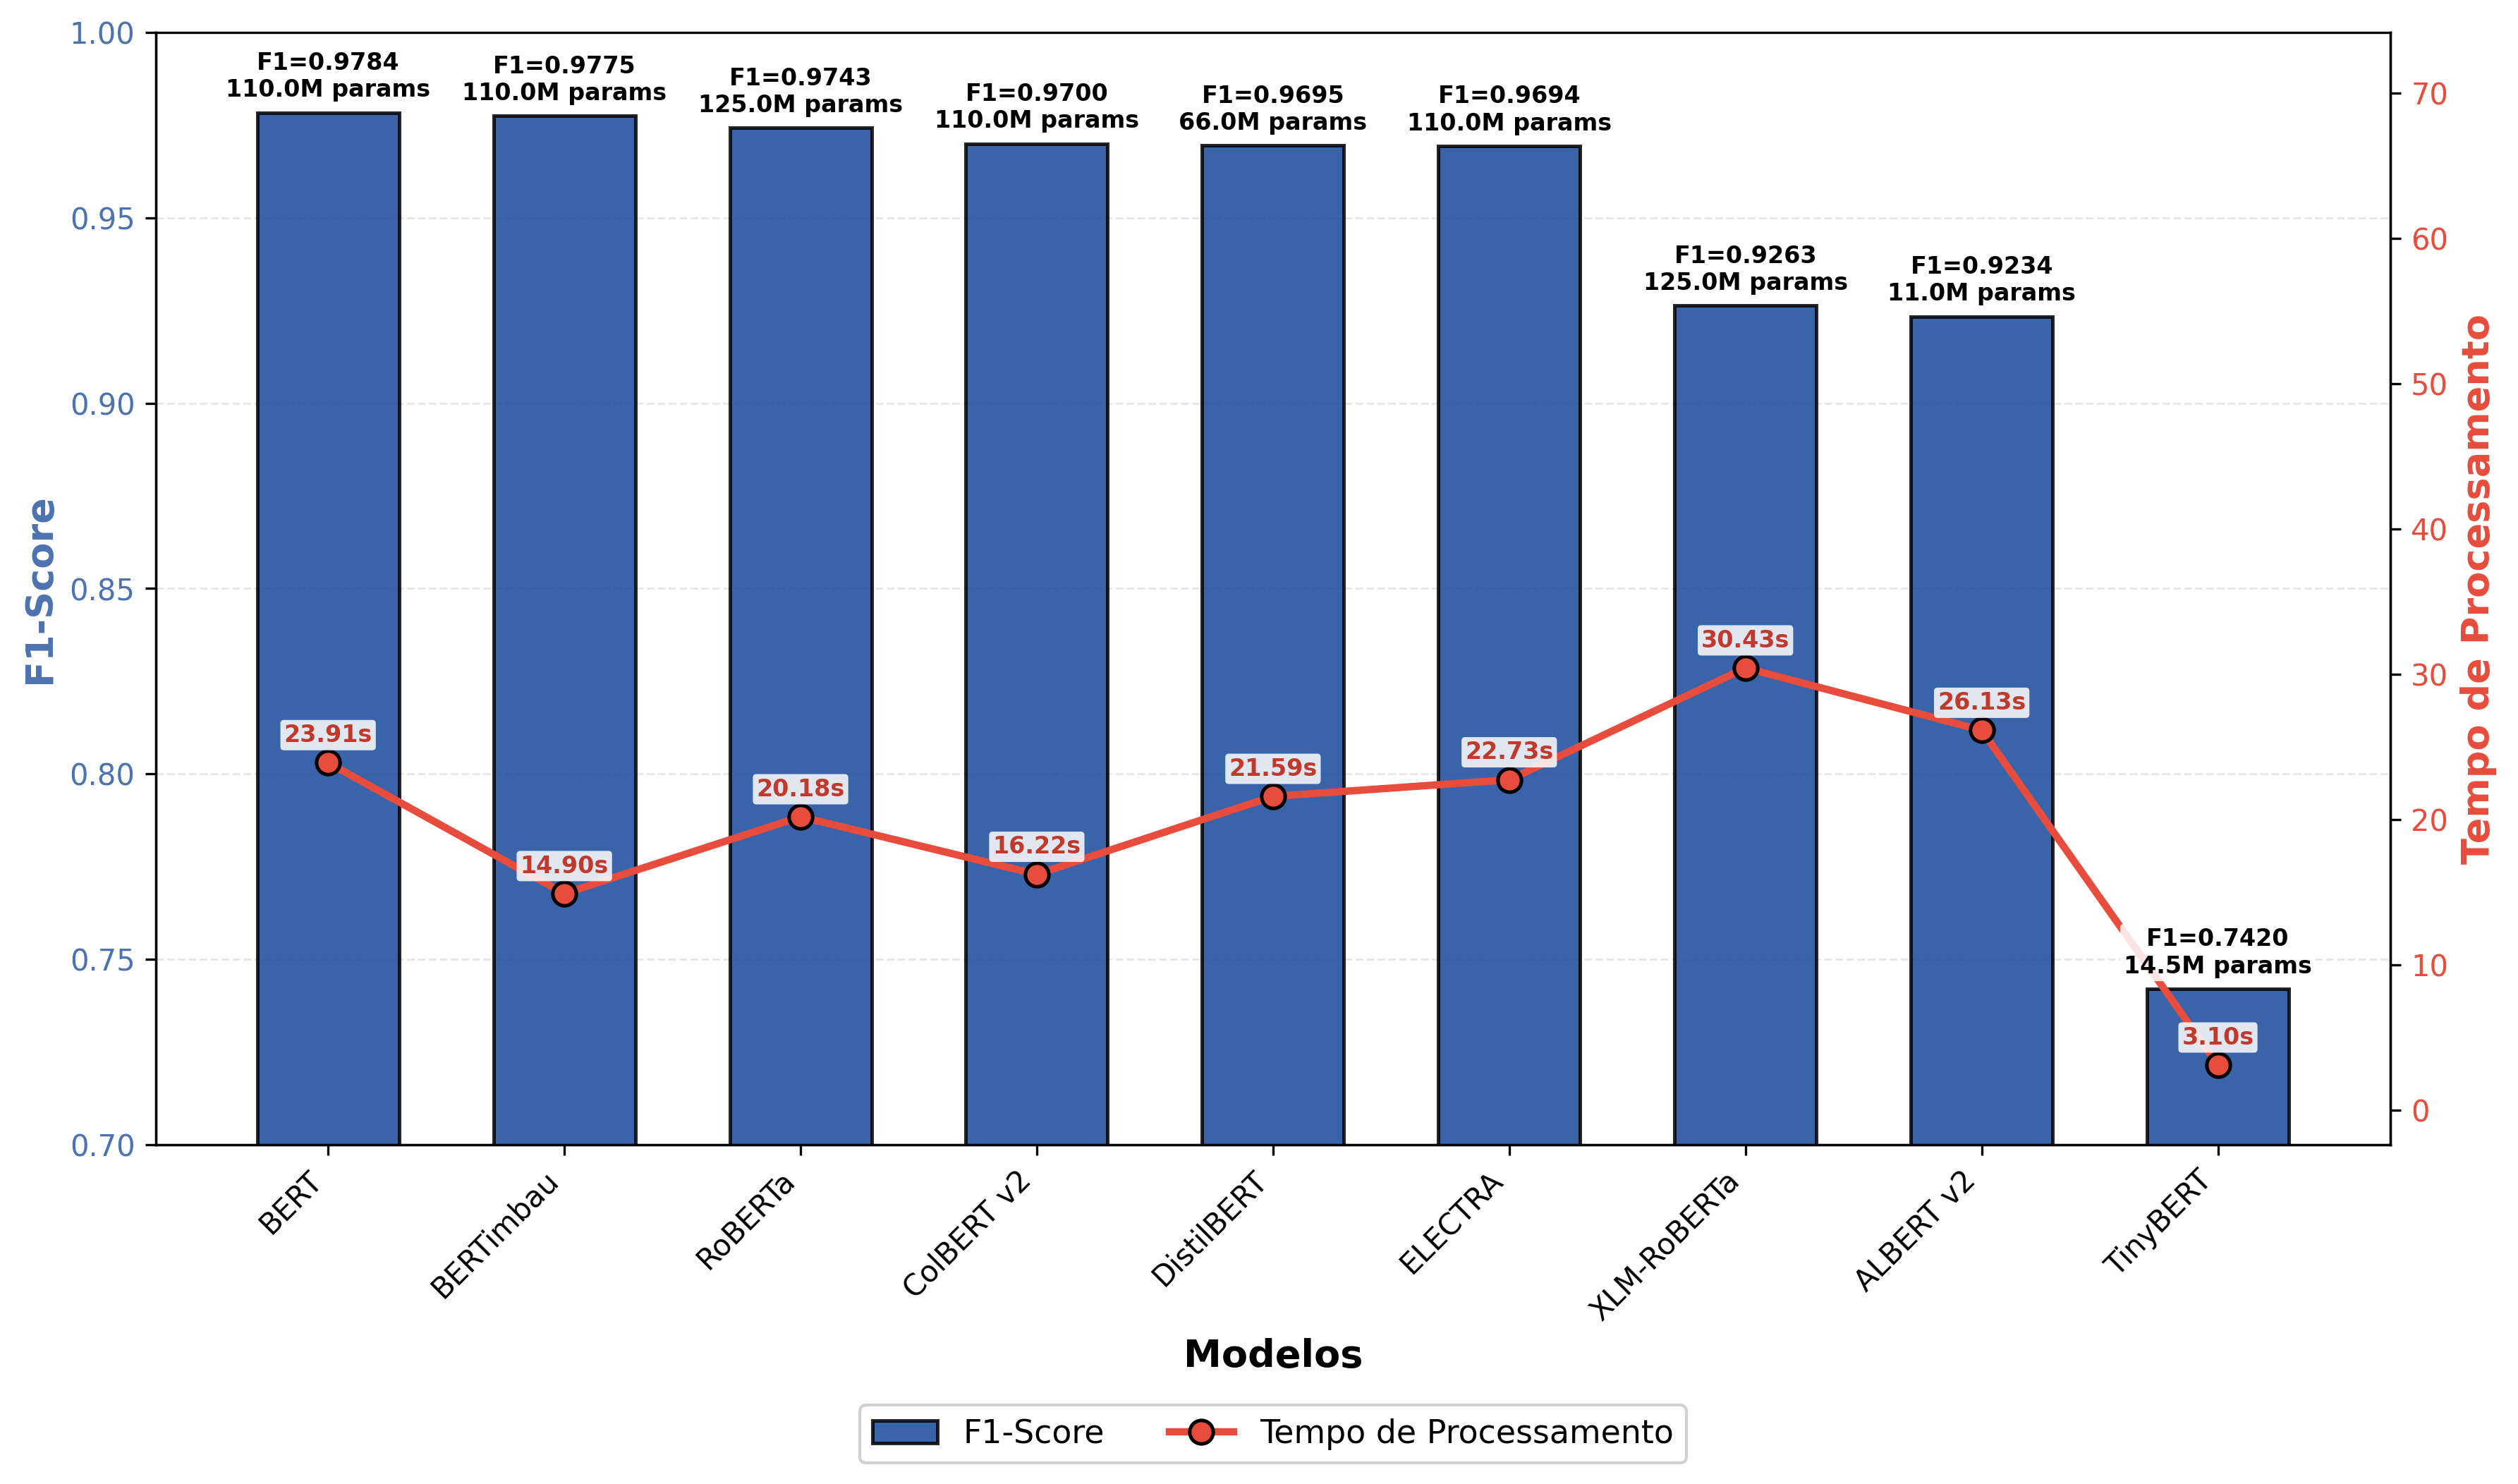


Dados dos Modelos Encoder:
Modelo                    Parâmetros (M)     F1-Score        Tempo (s/doc)  
-------------------------------------------------------------------------
BERT                      110.00             0.9784          23.91          
BERTimbau                 110.00             0.9775          14.90          
RoBERTa                   125.00             0.9743          20.18          
ColBERT v2                110.00             0.9700          16.22          
DistilBERT                66.00              0.9695          21.59          
ELECTRA                   110.00             0.9694          22.73          
XLM-RoBERTa               125.00             0.9263          30.43          
ALBERT v2                 11.00              0.9234          26.13          
TinyBERT                  14.50              0.7420          3.10           


: 

In [ ]:
# ==========================================
# Encoder Models: F1-Score vs Parâmetros
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ler dados de processamento
df_processing = pd.read_csv("peak_metric_results/encoder_processing_averages.csv")

# Mapear nomes do CSV para os nomes do dicionário
model_mapping = {
    "roberta_base": "RoBERTa",
    "xlm-roberta-base": "XLM-RoBERTa",
    "bert": "BERT",
    "bertimbau": "BERTimbau",
    "colbert_v2.0": "ColBERT v2",
    "electra-base-discriminator": "ELECTRA",
    "distilbert": "DistilBERT",
    "TinyBERT": "TinyBERT",
    "albert-base-v2": "ALBERT v2",
}

encoder_models = {
    "RoBERTa": {"params_m": 125, "f1": 0.9743},
    "XLM-RoBERTa": {"params_m": 125, "f1": 0.9263},
    "BERT": {"params_m": 110, "f1": 0.9784},
    "BERTimbau": {"params_m": 110, "f1": 0.9775},
    "ColBERT v2": {"params_m": 110, "f1": 0.9700},
    "ELECTRA": {"params_m": 110, "f1": 0.9694},
    "DistilBERT": {"params_m": 66, "f1": 0.9695},
    "TinyBERT": {"params_m": 14.5, "f1": 0.7420},
    "ALBERT v2": {"params_m": 11, "f1": 0.9234},
}

# Adicionar dados de tempo de processamento ao dicionário
for csv_name, model_name in model_mapping.items():
    if csv_name in df_processing["modelo"].values:
        tempo_total = df_processing[df_processing["modelo"] == csv_name]["tempo_total_s"].values[0]
        tempo_por_documento = tempo_total / 40
        encoder_models[model_name]["tempo_s"] = tempo_por_documento

# Preparar dados
names = list(encoder_models.keys())
params = np.array([encoder_models[m]["params_m"] for m in names])
f1_scores = np.array([encoder_models[m]["f1"] for m in names])
tempo_processamento = np.array([encoder_models[m].get("tempo_s", 0) for m in names])

# Ordenar por F1-Score em ordem decrescente
sorted_indices = np.argsort(f1_scores)[::-1]
f1_scores = f1_scores[sorted_indices]
params = params[sorted_indices]
tempo_processamento = tempo_processamento[sorted_indices]
names = [names[i] for i in sorted_indices]

# ==========================================
# Criar figura com eixos duplos
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 7), dpi=300)

x_pos = np.arange(len(names))
width = 0.6

# Eixo Y esquerda: F1-Score (barras)
bars = ax1.bar(
    x_pos,
    f1_scores,
    width=width,
    color="#17499A",
    alpha=0.85,
    edgecolor="black",
    linewidth=1.2,
    label="F1-Score",
    zorder=2,
)

ax1.set_xlabel("Modelos", fontsize=13, fontweight="bold")
ax1.set_ylabel("F1-Score", fontsize=13, fontweight="bold", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_ylim(0.7, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names, rotation=45, ha="right", fontsize=10)

ax1.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.7, zorder=0)
ax1.spines["top"].set_visible(False)

# ==========================================
# Eixo Y direita: Tempo de processamento
# ==========================================
ax2 = ax1.twinx()

# Definir ylim do ax2 ANTES das anotações para que a conversão
# de coordenadas seja calculada com os limites finais corretos.
t_min = tempo_processamento.min()
t_max = tempo_processamento.max()
ax2.set_ylim(t_min - (t_max - t_min) * 0.2,
             t_max + (t_max - t_min) * 1.6)  # bastante espaço no topo

line = ax2.plot(
    x_pos,
    tempo_processamento,
    color="#E74C3C",
    marker="o",
    linewidth=2.5,
    markersize=8,
    markeredgecolor="black",
    markeredgewidth=1.2,
    label="Tempo de Processamento",
    zorder=3,
)

ax2.set_ylabel(
    "Tempo de Processamento",
    fontsize=13,
    fontweight="bold",
    color="#E74C3C",
)
ax2.tick_params(axis="y", labelcolor="#E74C3C")

# ==========================================
# Anotações de F1/params desenhadas em ax2
# para garantir que ficam na frente da linha.
# Conversão: coordenada y de ax1 → display → ax2
# ==========================================
ax1_to_display = ax1.transData
display_to_ax2 = ax2.transData.inverted()

for bar, f1, p in zip(bars, f1_scores, params):
    x_data = bar.get_x() + bar.get_width() / 2
    y_ax1 = bar.get_height() + 0.003          # logo acima do topo da barra

    x_disp, y_disp = ax1_to_display.transform((x_data, y_ax1))
    x_ax2, y_ax2 = display_to_ax2.transform((x_disp, y_disp))

    ax2.text(
        x_ax2,
        y_ax2,
        f"F1={f1:.4f}\n{p:.1f}M params",
        ha="center",
        va="bottom",          # cresce para CIMA a partir do topo da barra
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# Anotações de tempo
for x, t in zip(x_pos, tempo_processamento):
    ax2.text(
        x,
        t + (t_max - t_min) * 0.04,   # pequeno offset proporcional ao range
        f"{t:.2f}s",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#C0392B",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# ==========================================
# Legenda FORA do gráfico — abaixo do eixo X
# ==========================================
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + line,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

# ==========================================
# Salvar figura
# ==========================================
plt.savefig("encoder_models_f1_vs_params.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nDados dos Modelos Encoder:")
print(f"{'Modelo':<25} {'Parâmetros (M)':<18} {'F1-Score':<15} {'Tempo (s/doc)':<15}")
print("-" * 73)
for name, p, f1, t in zip(names, params, f1_scores, tempo_processamento):
    print(f"{name:<25} {p:<18.2f} {f1:<15.4f} {t:<15.2f}")

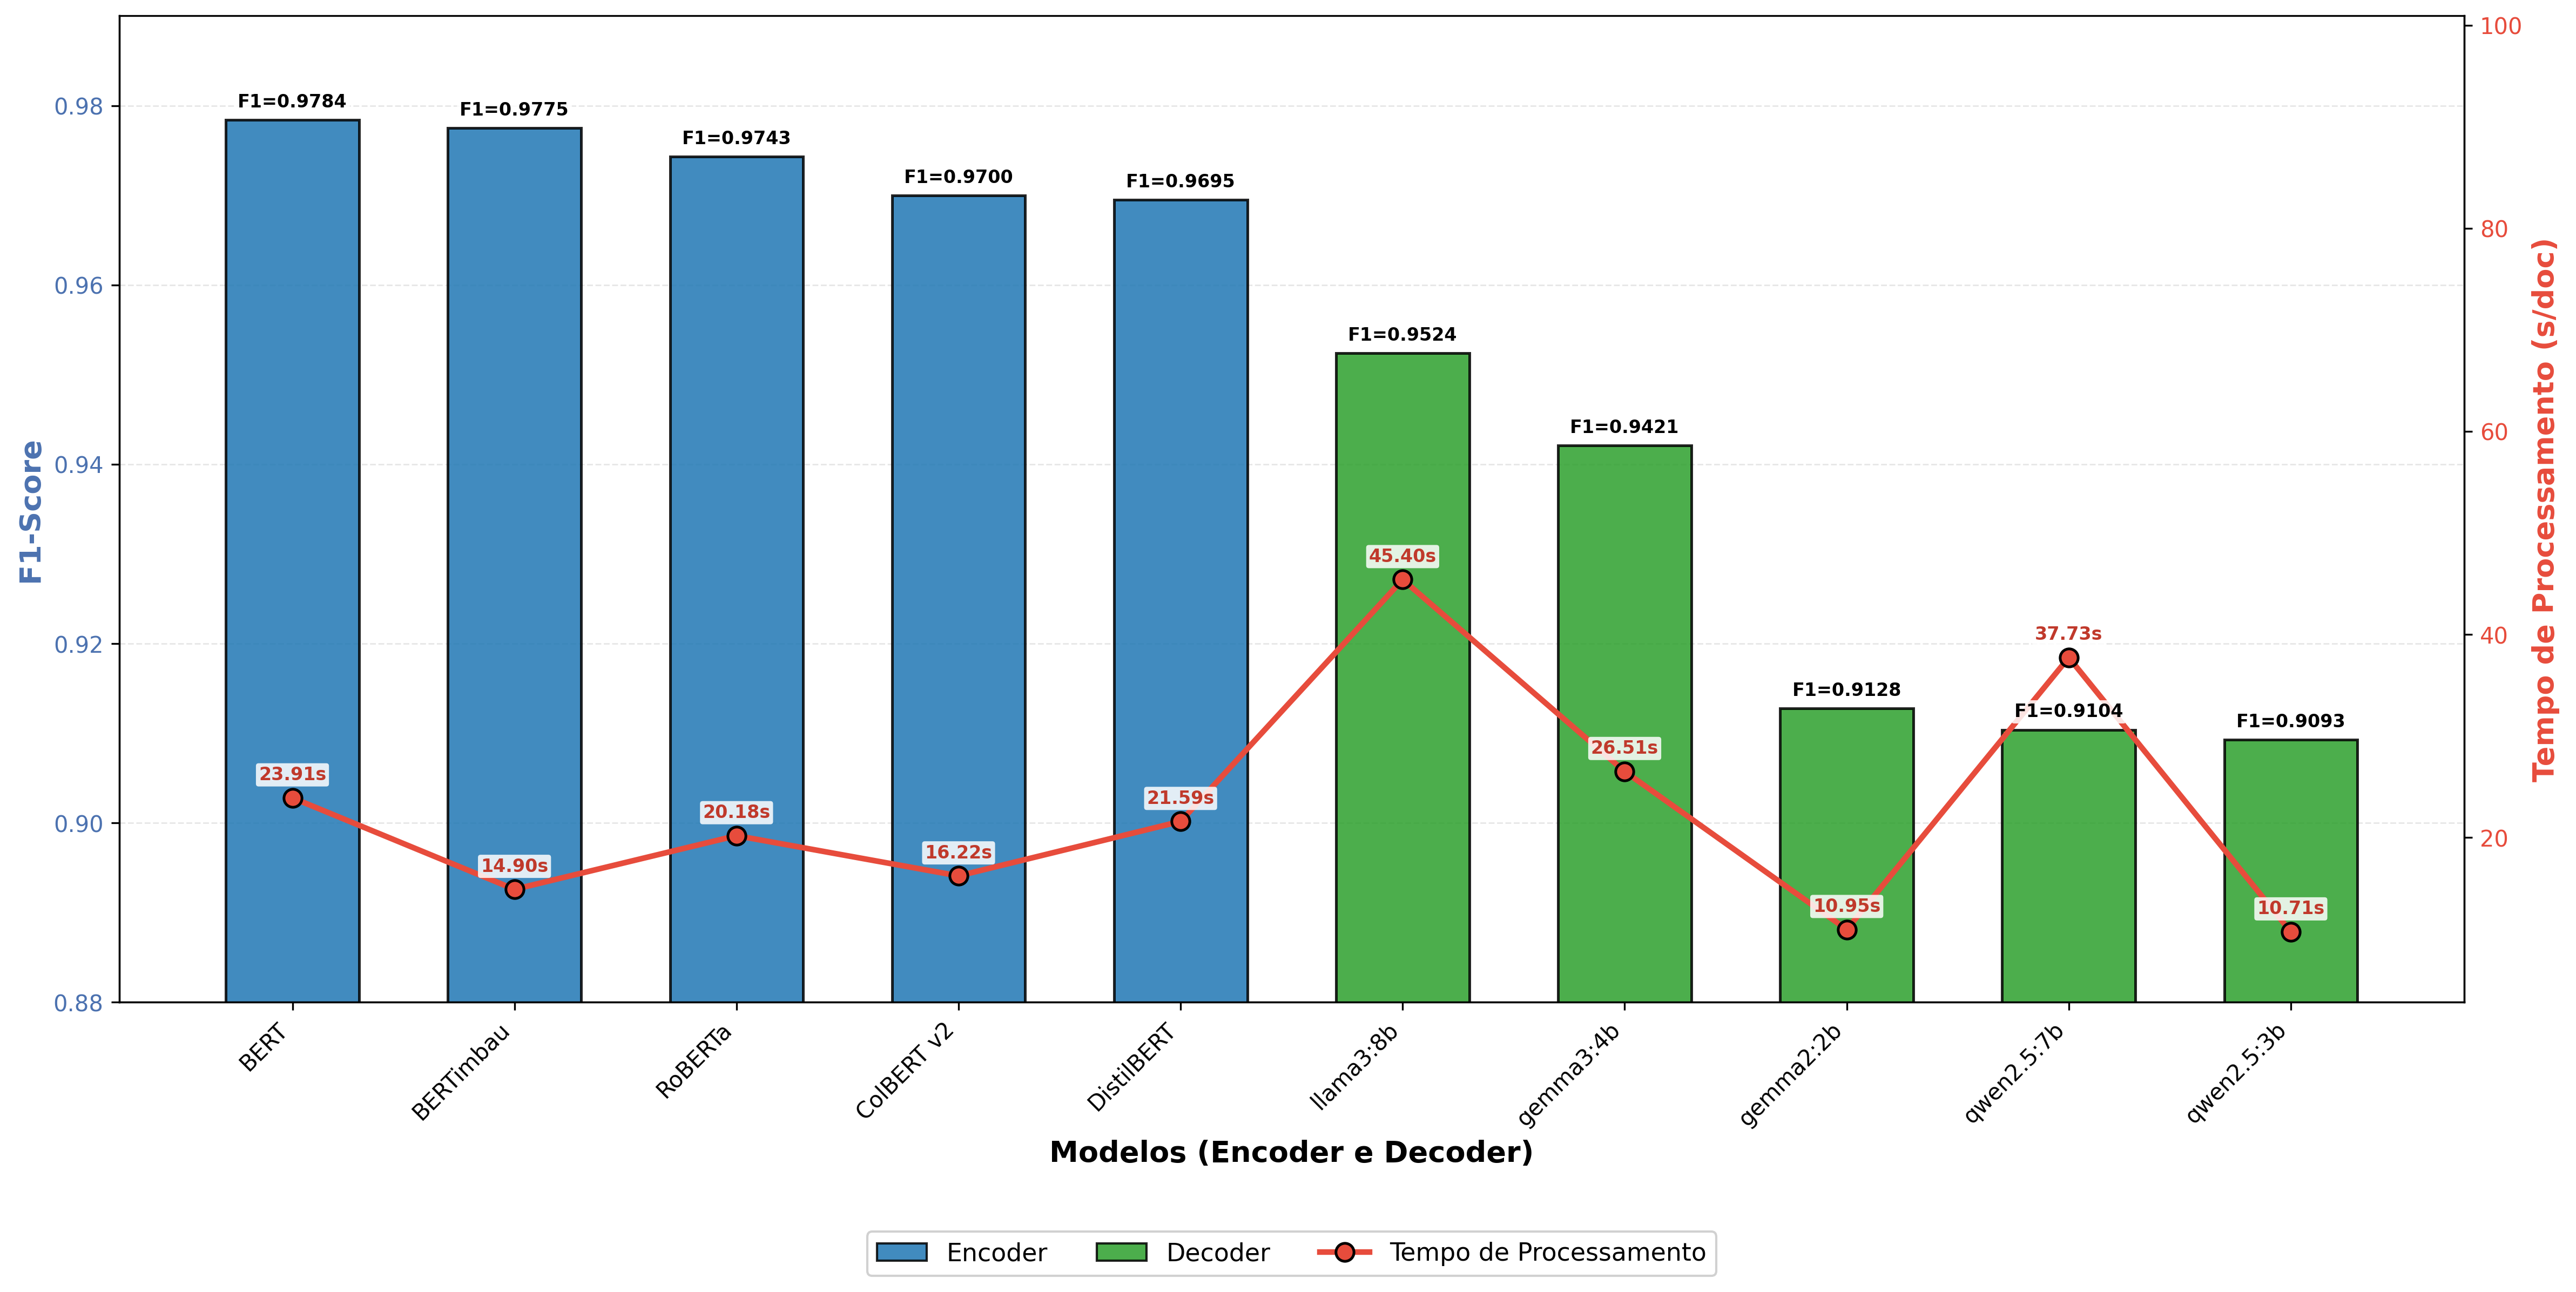


Top 5 Modelos Encoder e Decoder - F1-Score vs Tempo (Ordenado por F1-Score):
Modelo                    Tipo       F1-Score        Tempo (s/doc)  
-----------------------------------------------------------------
BERT                      Encoder    0.9784          23.91          
BERTimbau                 Encoder    0.9775          14.90          
RoBERTa                   Encoder    0.9743          20.18          
ColBERT v2                Encoder    0.9700          16.22          
DistilBERT                Encoder    0.9695          21.59          
llama3:8b                 Decoder    0.9524          45.40          
gemma3:4b                 Decoder    0.9421          26.51          
gemma2:2b                 Decoder    0.9128          10.95          
qwen2.5:7b                Decoder    0.9104          37.73          
qwen2.5:3b                Decoder    0.9093          10.71          


In [17]:
# ==========================================
# Top 5 Encoder e Decoder Models: F1-Score vs Tempo
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ==========================================
# ENCODER - Ler dados de processamento
# ==========================================
df_processing_enc = pd.read_csv("peak_metric_results/encoder_processing_averages.csv")

model_mapping_enc = {
    "roberta_base": "RoBERTa",
    "xlm-roberta-base": "XLM-RoBERTa",
    "bert": "BERT",
    "bertimbau": "BERTimbau",
    "colbert_v2.0": "ColBERT v2",
    "electra-base-discriminator": "ELECTRA",
    "distilbert": "DistilBERT",
    "TinyBERT": "TinyBERT",
    "albert-base-v2": "ALBERT v2",
}

encoder_models = {
    "RoBERTa": {"f1": 0.9743},
    "XLM-RoBERTa": {"f1": 0.9263},
    "BERT": {"f1": 0.9784},
    "BERTimbau": {"f1": 0.9775},
    "ColBERT v2": {"f1": 0.9700},
    "ELECTRA": {"f1": 0.9694},
    "DistilBERT": {"f1": 0.9695},
    "TinyBERT": {"f1": 0.7420},
    "ALBERT v2": {"f1": 0.9234},
}

for csv_name, model_name in model_mapping_enc.items():
    if csv_name in df_processing_enc["modelo"].values:
        tempo_total = df_processing_enc[df_processing_enc["modelo"] == csv_name]["tempo_total_s"].values[0]
        encoder_models[model_name]["tempo_s"] = tempo_total / 40

# Preparar dados encoder
encoder_names = list(encoder_models.keys())
encoder_f1 = np.array([encoder_models[m]["f1"] for m in encoder_names])
encoder_tempo = np.array([encoder_models[m].get("tempo_s", 0) for m in encoder_names])

# Ordenar por F1-Score e pegar top 5
sorted_indices = np.argsort(encoder_f1)[::-1][:5]
encoder_f1 = encoder_f1[sorted_indices]
encoder_tempo = encoder_tempo[sorted_indices]
encoder_names = [encoder_names[i] for i in sorted_indices]

# ==========================================
# DECODER - Ler dados de processamento
# ==========================================
df_processing_dec = pd.read_csv("metric_results/decoder_processing_averages.csv")

decoder_f1_scores = {
    "mistral:7b": 0.8756,
    "llama3:8b": 0.9524,
    "gemma2:2b": 0.9128,
    "qwen2.5:0.5b": 0.5942,
    "qwen2.5:1.5b": 0.8136,
    "qwen2.5:3b": 0.9093,
    "qwen2.5:7b": 0.9104,
    "llama3.2:1b": 0.4197,
    "llama3.2:3b": 0.8629,
    "deepseek-r1:1.5b": 0.1614,
    "deepseek-r1:7b": 0.7752,
    "gemma3:270m": 0.0904,
    "gemma3:4b": 0.9421,
}

decoder_models = {}
for idx, row in df_processing_dec.iterrows():
    model = row["modelo"]
    if model in decoder_f1_scores:
        decoder_models[model] = {
            "f1": decoder_f1_scores[model],
            "tempo_s": row["tempo_total_s"] / 40,
        }

# Preparar dados decoder
decoder_names = list(decoder_models.keys())
decoder_f1 = np.array([decoder_models[m]["f1"] for m in decoder_names])
decoder_tempo = np.array([decoder_models[m]["tempo_s"] for m in decoder_names])

# Ordenar por F1-Score e pegar top 5
sorted_indices = np.argsort(decoder_f1)[::-1][:5]
decoder_f1 = decoder_f1[sorted_indices]
decoder_tempo = decoder_tempo[sorted_indices]
decoder_names = [decoder_names[i] for i in sorted_indices]

# ==========================================
# Combinar dados
# ==========================================
# Nomes sem sufixo — a cor da barra identifica o tipo
all_names = encoder_names + decoder_names
all_f1 = np.concatenate([encoder_f1, decoder_f1])
all_tempo = np.concatenate([encoder_tempo, decoder_tempo])
colors_bars = ["#1f77b4"] * len(encoder_names) + ["#2ca02c"] * len(decoder_names)
# Rótulo do tipo para uso na tabela (sem aparecer no gráfico)
all_tipos = ["Encoder"] * len(encoder_names) + ["Decoder"] * len(decoder_names)

# Ordenar tudo por F1-Score decrescente
sorted_indices_all = np.argsort(all_f1)[::-1]
all_names = [all_names[i] for i in sorted_indices_all]
all_f1 = all_f1[sorted_indices_all]
all_tempo = all_tempo[sorted_indices_all]
colors_bars = [colors_bars[i] for i in sorted_indices_all]
all_tipos = [all_tipos[i] for i in sorted_indices_all]

# ==========================================
# Criar figura com eixos duplos
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 8), dpi=300)

x_pos = np.arange(len(all_names))
width = 0.6

# Eixo Y esquerda: F1-Score (barras)
bars = ax1.bar(
    x_pos,
    all_f1,
    width=width,
    color=colors_bars,
    alpha=0.85,
    edgecolor="black",
    linewidth=1.2,
    zorder=2,
)

ax1.set_xlabel("Modelos (Encoder e Decoder)", fontsize=13, fontweight="bold")
ax1.set_ylabel("F1-Score", fontsize=13, fontweight="bold", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_ylim(0.88, 0.99)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha="right", fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.7, zorder=0)
ax1.spines["top"].set_visible(False)

# ==========================================
# Eixo Y direita: Tempo de processamento
# ==========================================
ax2 = ax1.twinx()

# Definir ylim do ax2 ANTES das anotações para que a conversão
# de coordenadas seja calculada com os limites finais corretos.
t_min = all_tempo.min()
t_max = all_tempo.max()
ax2.set_ylim(
    t_min - (t_max - t_min) * 0.2,
    t_max + (t_max - t_min) * 1.6,  # bastante espaço no topo
)

line = ax2.plot(
    x_pos,
    all_tempo,
    color="#E74C3C",
    marker="o",
    linewidth=2.5,
    markersize=8,
    markeredgecolor="black",
    markeredgewidth=1.2,
    label="Tempo de Processamento",
    zorder=3,
)

ax2.set_ylabel(
    "Tempo de Processamento (s/doc)",
    fontsize=13,
    fontweight="bold",
    color="#E74C3C",
)
ax2.tick_params(axis="y", labelcolor="#E74C3C")

# ==========================================
# Anotações de F1 desenhadas em ax2
# para garantir que ficam na frente da linha.
# Conversão: coordenada y de ax1 → display → ax2
# ==========================================
ax1_to_display = ax1.transData
display_to_ax2 = ax2.transData.inverted()

for bar, f1 in zip(bars, all_f1):
    x_data = bar.get_x() + bar.get_width() / 2
    y_ax1 = bar.get_height() + 0.001          # logo acima do topo da barra
    x_disp, y_disp = ax1_to_display.transform((x_data, y_ax1))
    x_ax2, y_ax2 = display_to_ax2.transform((x_disp, y_disp))

    ax2.text(
        x_ax2,
        y_ax2,
        f"F1={f1:.4f}",
        ha="center",
        va="bottom",          # cresce para CIMA a partir do topo da barra
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# Anotações de tempo
for x, t in zip(x_pos, all_tempo):
    ax2.text(
        x,
        t + (t_max - t_min) * 0.04,   # pequeno offset proporcional ao range
        f"{t:.2f}s",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#C0392B",
        zorder=6,
        bbox=dict(
            boxstyle="round,pad=0.15",
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
        ),
    )

# ==========================================
# Legenda FORA do gráfico — abaixo do eixo X
# ==========================================
legend_elements = [
    mpatches.Patch(facecolor="#1f77b4", edgecolor="black", label="Encoder", alpha=0.85),
    mpatches.Patch(facecolor="#2ca02c", edgecolor="black", label="Decoder", alpha=0.85),
    plt.Line2D(
        [0], [0],
        color="#E74C3C",
        linewidth=2.5,
        marker="o",
        markersize=8,
        markeredgecolor="black",
        markeredgewidth=1.2,
        label="Tempo de Processamento",
    ),
]

ax1.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

# ==========================================
# Salvar figura
# ==========================================
plt.savefig("top5_models_f1_vs_tempo.png", bbox_inches="tight", dpi=300)
plt.show()

# ==========================================
# Exibir dados em tabela combinada
# ==========================================
print("\nTop 5 Modelos Encoder e Decoder - F1-Score vs Tempo (Ordenado por F1-Score):")
print(f"{'Modelo':<25} {'Tipo':<10} {'F1-Score':<15} {'Tempo (s/doc)':<15}")
print("-" * 65)
for name, tipo, f1, t in zip(all_names, all_tipos, all_f1, all_tempo):
    print(f"{name:<25} {tipo:<10} {f1:<15.4f} {t:<15.2f}")